In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_origginal = pd.read_csv("data/german_credit_data.csv")

In [3]:
df = df_origginal.copy()

In [4]:
df.shape

(1000, 11)

In [5]:
df.tail()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad
999,999,27,male,2,own,moderate,moderate,4576,45,car,good


In [6]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [7]:
df.head(10)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
5,5,35,male,1,free,NaN,NaN,9055,36,education,good
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,7,35,male,3,rent,little,moderate,6948,36,car,good
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [9]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [10]:
df.Purpose.unique()

<StringArray>
[           'radio/TV',           'education', 'furniture/equipment',
                 'car',            'business', 'domestic appliances',
             'repairs',     'vacation/others']
Length: 8, dtype: str

In [11]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [12]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [13]:
df['Risk'].unique()

<StringArray>
['good', 'bad']
Length: 2, dtype: str

In [14]:
df.Risk.value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [15]:
df.Risk.value_counts(normalize=True) * 100

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

In [16]:
df.groupby('Job').Risk.value_counts(normalize=True).unstack() * 100

Risk,bad,good
Job,,
0,31.818182,68.181818
1,28.000000,72.000000
2,29.523810,70.476190
3,34.459459,65.540541


In [17]:
df['Saving accounts'].value_counts(dropna=False)

Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

/var/folders/d0/lztbr3wd2tn_sgnr156pff7c0000gn/T/ipykernel_70894/215475683.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


Variáveis categóricas: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']



Risco por Sex (em %)
Risk      bad   good
Sex                 
female  35.16  64.84
male    27.68  72.32
All     30.00  70.00

Risco por Housing (em %)
Risk       bad   good
Housing              
free     40.74  59.26
own      26.09  73.91
rent     39.11  60.89
All      30.00  70.00

Risco por Saving accounts (em %)
Risk               bad   good
Saving accounts              
little           35.99  64.01
moderate         33.01  66.99
quite rich       17.46  82.54
rich             12.50  87.50
All              32.80  67.20

Risco por Checking account (em %)
Risk                bad   good
Checking account              
little            49.27  50.73
moderate          39.03  60.97
rich              22.22  77.78
All               41.91  58.09

Risco por Purpose (em %)
Risk                   bad   good
Purpose                          
business             35.05  64.95
car                  31.45  

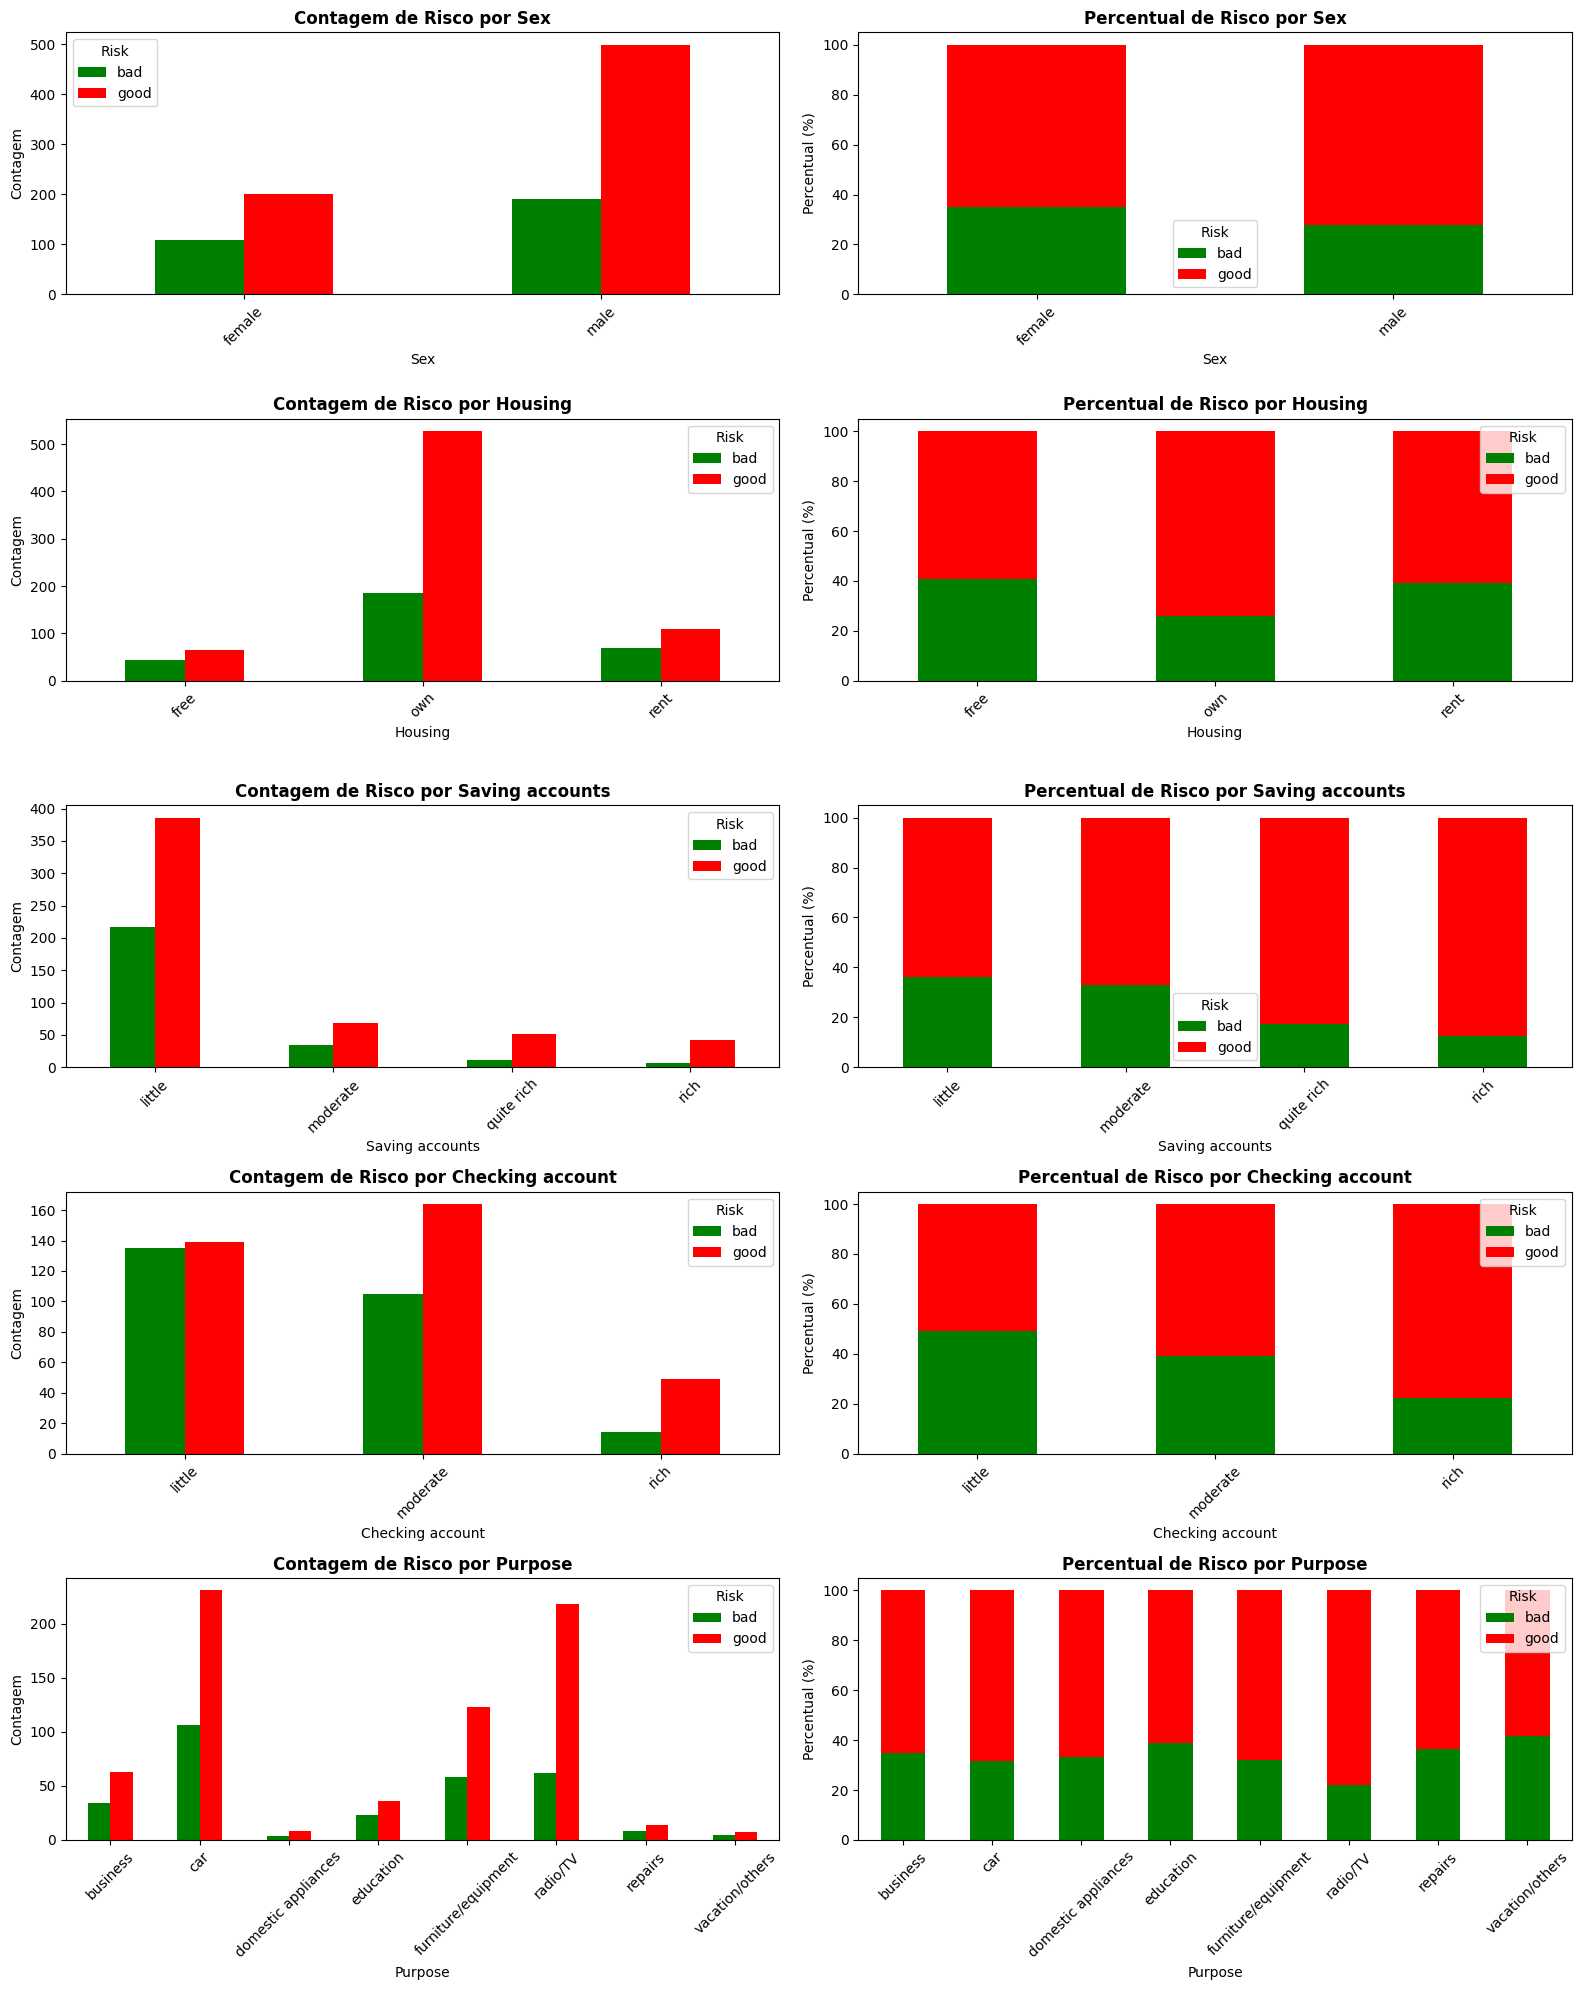


RESUMO GERAL DE RISCO
Risk
good    700
bad     300
Name: count, dtype: int64

Percentual:
Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64


In [18]:
# Identificar variáveis categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Risk')  # Remove a variável alvo

print("Variáveis categóricas:", categorical_cols)
print("\n")

# Criar uma figura com subplots para os gráficos
fig, axes = plt.subplots(len(categorical_cols), 2, figsize=(16, 4*len(categorical_cols)))

for idx, col in enumerate(categorical_cols):
    # Tabela: contagem e percentual de risco por categoria
    risk_by_cat = pd.crosstab(df[col], df['Risk'], margins=True, normalize='index') * 100
    print(f"\n{'='*60}")
    print(f"Risco por {col} (em %)")
    print(f"{'='*60}")
    print(risk_by_cat.round(2))
    
    # Gráfico 1: Contagem absoluta (stacked bar)
    crosstab_count = pd.crosstab(df[col], df['Risk'])
    crosstab_count.plot(kind='bar', stacked=False, ax=axes[idx, 0], color=['green', 'red'])
    axes[idx, 0].set_title(f'Contagem de Risco por {col}', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('Contagem')
    axes[idx, 0].legend(title='Risk')
    axes[idx, 0].tick_params(axis='x', rotation=45)
    
    # Gráfico 2: Percentual (100% stacked bar)
    crosstab_pct = pd.crosstab(df[col], df['Risk'], normalize='index') * 100
    crosstab_pct.plot(kind='bar', stacked=True, ax=axes[idx, 1], color=['green', 'red'])
    axes[idx, 1].set_title(f'Percentual de Risco por {col}', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel(col)
    axes[idx, 1].set_ylabel('Percentual (%)')
    axes[idx, 1].legend(title='Risk')
    axes[idx, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Resumo geral
print(f"\n{'='*60}")
print("RESUMO GERAL DE RISCO")
print(f"{'='*60}")
print(df.Risk.value_counts())
print("\nPercentual:")
print((df.Risk.value_counts(normalize=True) * 100).round(2))

Variáveis numéricas: ['Unnamed: 0', 'Age', 'Job', 'Credit amount', 'Duration']



Estatísticas de Unnamed: 0
count    1000.000000
mean      499.500000
std       288.819436
min         0.000000
25%       249.750000
50%       499.500000
75%       749.250000
max       999.000000
Name: Unnamed: 0, dtype: float64

Estatísticas de Age
count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

Estatísticas de Job
count    1000.000000
mean        1.904000
std         0.653614
min         0.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: Job, dtype: float64

Estatísticas de Credit amount
count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64

Estatísticas de 

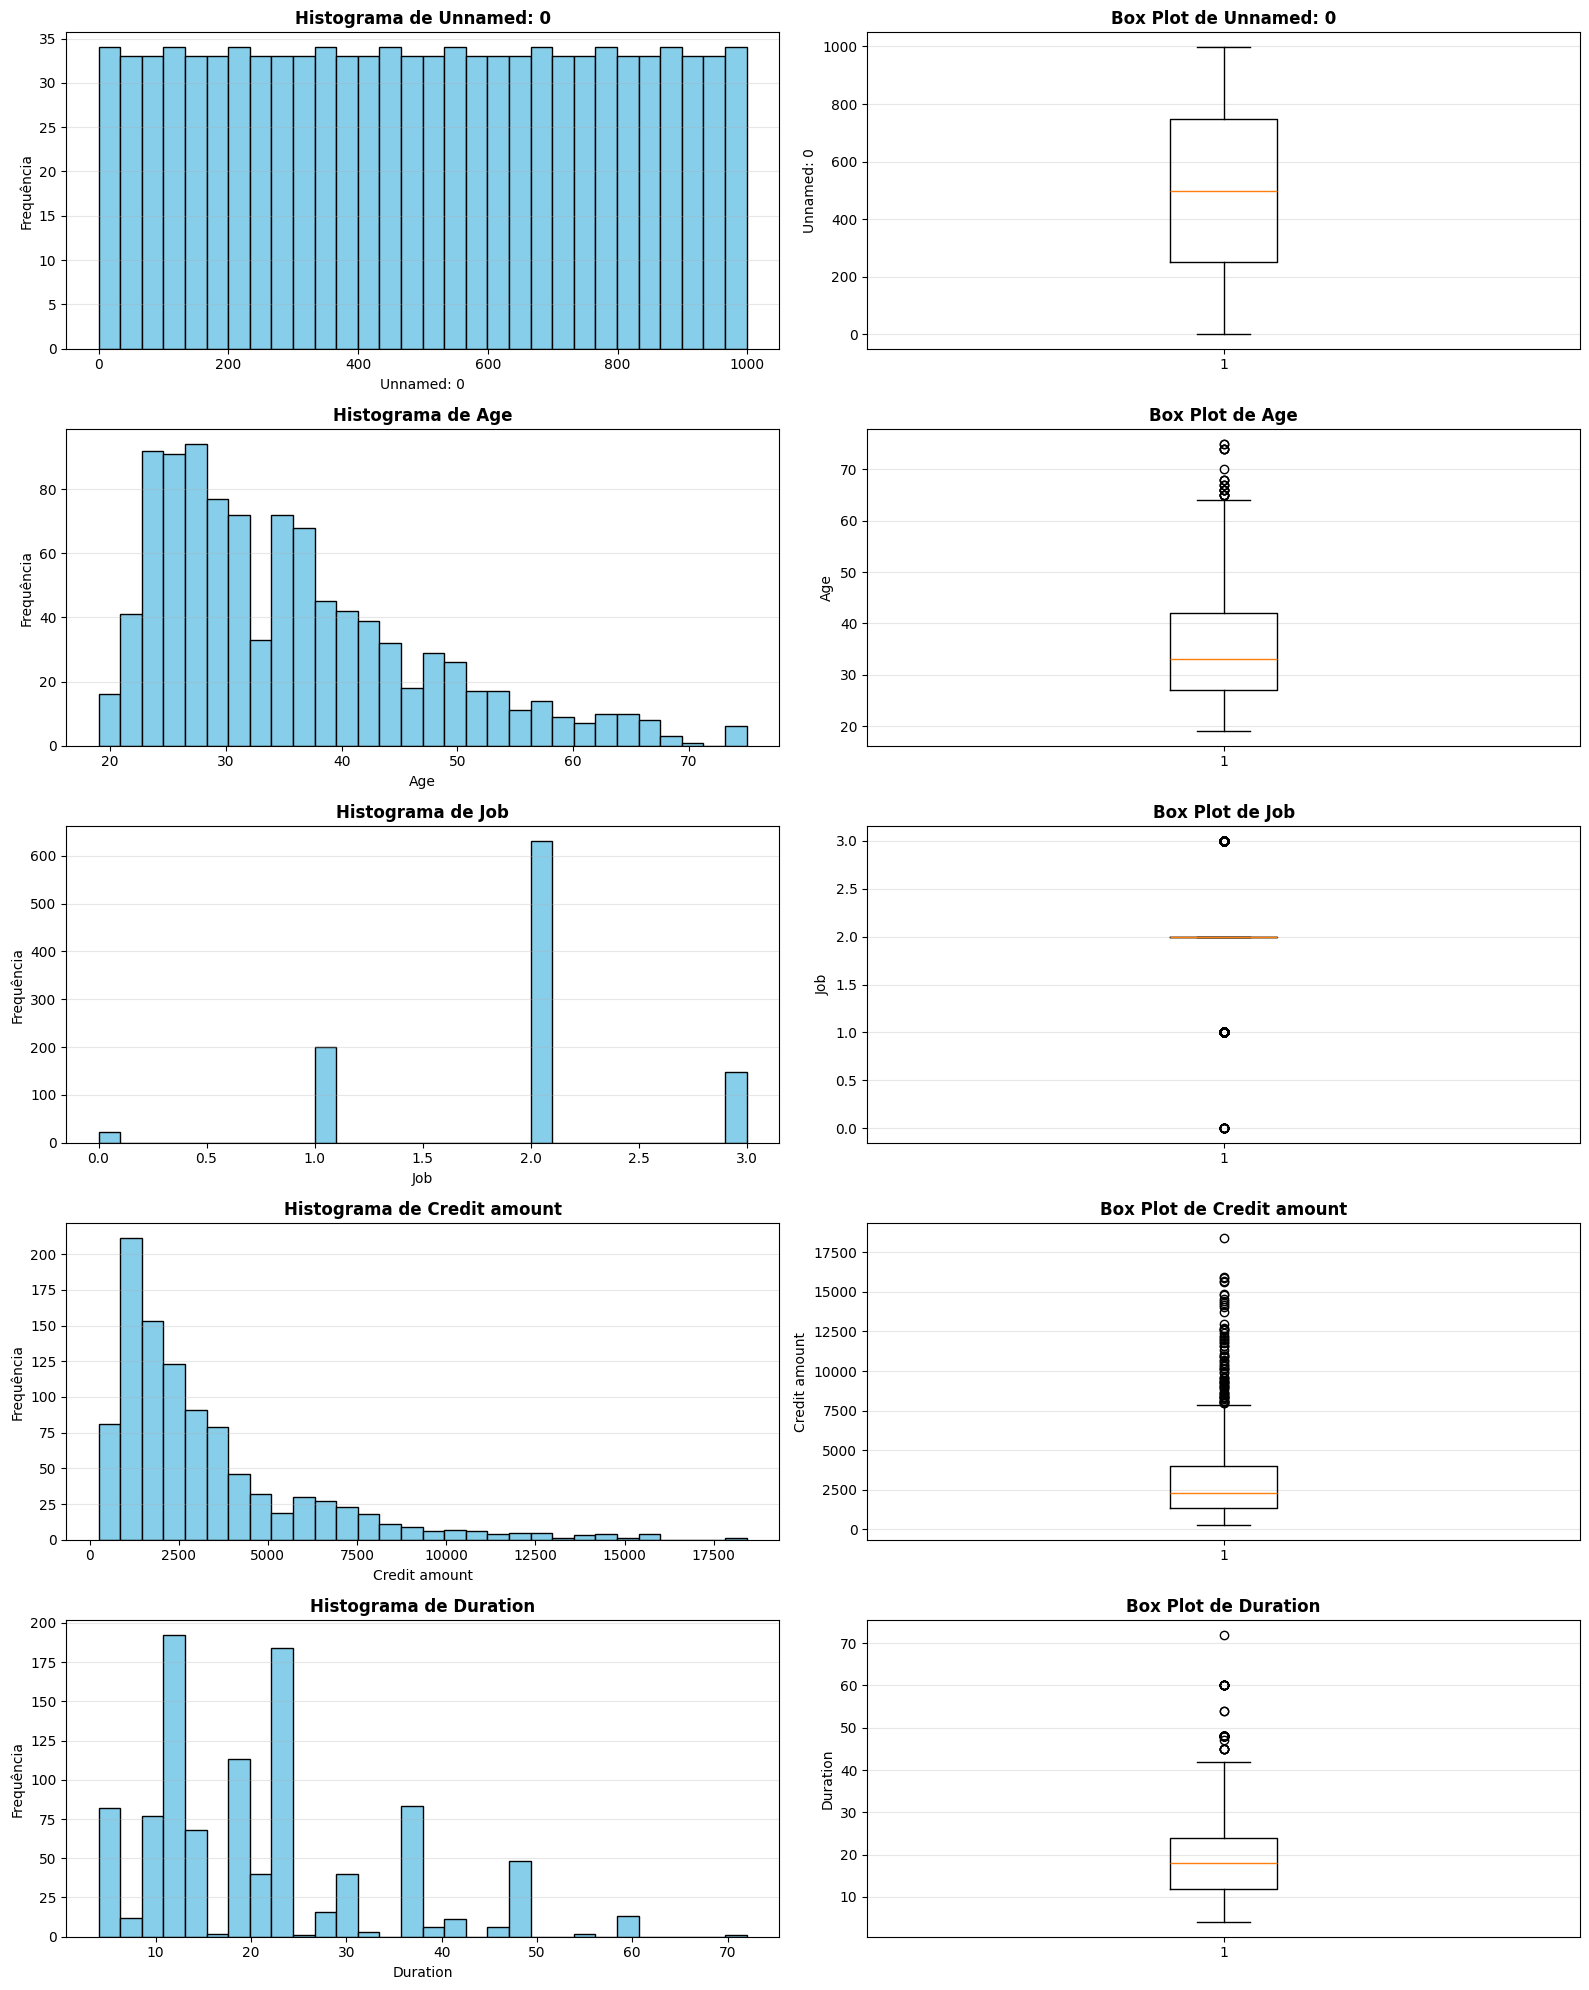


RESUMO GERAL DAS VARIÁVEIS NUMÉRICAS
       Unnamed: 0      Age      Job  Credit amount  Duration
count     1000.00  1000.00  1000.00        1000.00   1000.00
mean       499.50    35.55     1.90        3271.26     20.90
std        288.82    11.38     0.65        2822.74     12.06
min          0.00    19.00     0.00         250.00      4.00
25%        249.75    27.00     2.00        1365.50     12.00
50%        499.50    33.00     2.00        2319.50     18.00
75%        749.25    42.00     2.00        3972.25     24.00
max        999.00    75.00     3.00       18424.00     72.00


In [19]:
# Identificar variáveis numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Variáveis numéricas:", numeric_cols)
print("\n")

# Criar uma figura com subplots para os gráficos
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(16, 4*len(numeric_cols)))

for idx, col in enumerate(numeric_cols):
    # Estatísticas descritivas
    print(f"\n{'='*60}")
    print(f"Estatísticas de {col}")
    print(f"{'='*60}")
    print(df[col].describe())
    
    # Gráfico 1: Histograma com distribuição
    axes[idx, 0].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[idx, 0].set_title(f'Histograma de {col}', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('Frequência')
    axes[idx, 0].grid(axis='y', alpha=0.3)
    
    # Gráfico 2: Box plot
    axes[idx, 1].boxplot(df[col].dropna(), vert=True)
    axes[idx, 1].set_title(f'Box Plot de {col}', fontsize=12, fontweight='bold')
    axes[idx, 1].set_ylabel(col)
    axes[idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Resumo geral das variáveis numéricas
print(f"\n{'='*60}")
print("RESUMO GERAL DAS VARIÁVEIS NUMÉRICAS")
print(f"{'='*60}")
print(df[numeric_cols].describe().round(2))